In [136]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools import DuckDuckGoSearchRun

In [137]:
load_dotenv()

True

In [138]:
llm=ChatGroq(model="llama-3.1-8b-instant")

In [139]:

search_tool=DuckDuckGoSearchRun()

In [140]:
search_tool.invoke("what is a gdp of india?")

"Gross domestic product (GDP) is the market value of all final goods and services from a nation in a given year. [2] Countries are sorted by nominal GDP estimates from financial and statistical institutions, which are calculated at market or government official exchange rates. See full list on en.wikipedia.org GDP (current US$) - India Country official statistics, National Statistical Organizations and/or Central Banks; National Accounts data files, Organisation for Economic Co-operation and Development ( OECD ); Staff estimates, World Bank ( WB ) The Gross Domestic Product (GDP) in India was worth 3912.69 billion US dollars in 2024, according to official data from the World Bank. The GDP value of India represents 3.69 percent of the world economy. May 26, 2025 · India has overtaken Japan with a GDP of $4.19 trillion, becoming the 4th largest economy globally in 2025, confirms IMF data. Learn what this means for India’s global role, growth, and future trajectory. India Comprehensive ec

In [141]:

repl=PythonREPL()

In [142]:
code = """
x = 5
y = x * 2
print(y)
"""

In [143]:
repl.run(code)

'10\n'

In [144]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [145]:
def make_system_prompt(instruction: str) -> str:
    return f"""
You are a collaborative AI assistant working in a multi-agent system.

STRICT RULES:
1. Use ONLY the tools explicitly provided.
2. NEVER call tools that are unavailable.
3. NEVER invent tool names.
4. If you cannot fully complete the task, hand off to another assistant.
5. ONLY use 'FINAL ANSWER' when the ENTIRE task is fully completed.
6. If another assistant still needs to continue, DO NOT say FINAL ANSWER.
7. Instead, clearly describe what remains to be done.
8. DO NOT CALL TOOLS other than search_tool and python_repl_tool, PLEASE
{instruction}
""".strip()

In [146]:
def get_next_node(last_message:BaseMessage,goto:str):
    if "FINAL ANSWER" in last_message.content:
        return END
    return goto

In [147]:
research_agent=create_react_agent(
    llm,
    tools=[search_tool],
    prompt=make_system_prompt(
        """
You are a researcher agent.

Your responsibilities:
- Find GDP data
- Provide clean numerical values
- Pass the data to the chart generator

You CANNOT generate charts.

IMPORTANT:
- NEVER say FINAL ANSWER unless the chart already exists.
- After collecting data, explicitly hand off to the chart generator.
"""
    ),
)

/var/folders/qz/mw466yp17txddtx0y1qsb1q00000gn/T/ipykernel_3169/2820910158.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent=create_react_agent(


In [148]:
chart_agent=create_react_agent(
    llm,
    tools=[python_repl_tool],
    prompt=make_system_prompt(
        """
You are a chart generation agent.

Your ONLY responsibility:
- Generate charts using Python.

When the chart is successfully generated,
respond with FINAL ANSWER.
"""
    ),
)

/var/folders/qz/mw466yp17txddtx0y1qsb1q00000gn/T/ipykernel_3169/1401694328.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent=create_react_agent(


In [149]:
def research_node(state:MessagesState)->Command[Literal["chart_generator",END]]:
    result=research_agent.invoke(state)
    
    goto=get_next_node(result["messages"][-1],"chart_generator")

    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")

    return Command(update={"messages":result["messages"]},goto=goto)

In [150]:
def chart_node(state:MessagesState)-> Command[Literal["researcher", END]]:
    
    result = chart_agent.invoke(state)
    
    goto = get_next_node(result["messages"][-1], "researcher")
    
    result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")
    
    return Command(update={"messages": result["messages"]},goto=goto)

In [151]:
from langgraph.graph import StateGraph, START

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

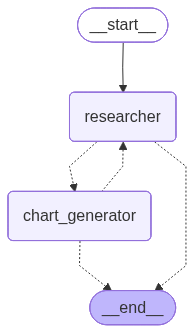

In [152]:
display(Image(app.get_graph().draw_mermaid_png()))

In [155]:

app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: attempted to call tool 'search_tool' which was not in request.tools", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=search_tool>{"query": "UK GDP data past 3 years"}</function>\n\n'}}